In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/logon.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/device.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/psychometric.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/http.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/readme.txt
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/license.txt
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/email.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/file.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-08.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2011-03.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-10.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-02.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-03.csv
/kaggle/input/datasets/revsyko/insider-threat-

In [2]:
#imports
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
base_path = "/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/"

datasets = {
    "logon": pl.scan_csv(base_path + "logon.csv"),
    "device": pl.scan_csv(base_path + "device.csv"),
    "email": pl.scan_csv(base_path + "email.csv"),
    "file": pl.scan_csv(base_path + "file.csv"),
    "http": pl.scan_csv(base_path + "http.csv"),
    "psychometric": pl.scan_csv(base_path + "psychometric.csv")
}

In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.head().collect())


LOGON
shape: (5, 5)
┌──────────────────────────┬─────────────────────┬─────────┬─────────┬──────────┐
│ id                       ┆ date                ┆ user    ┆ pc      ┆ activity │
│ ---                      ┆ ---                 ┆ ---     ┆ ---     ┆ ---      │
│ str                      ┆ str                 ┆ str     ┆ str     ┆ str      │
╞══════════════════════════╪═════════════════════╪═════════╪═════════╪══════════╡
│ {X1D9-S0ES98JV-5357PWMI} ┆ 01/02/2010 06:49:00 ┆ NGF0157 ┆ PC-6056 ┆ Logon    │
│ {G2B3-L6EJ61GT-2222RKSO} ┆ 01/02/2010 06:50:00 ┆ LRR0148 ┆ PC-4275 ┆ Logon    │
│ {U6Q3-U0WE70UA-3770UREL} ┆ 01/02/2010 06:53:04 ┆ LRR0148 ┆ PC-4124 ┆ Logon    │
│ {I0N5-R7NA26TG-6263KNGM} ┆ 01/02/2010 07:00:00 ┆ IRM0931 ┆ PC-7188 ┆ Logon    │
│ {D1S0-N6FH62BT-5398KANK} ┆ 01/02/2010 07:00:00 ┆ MOH0273 ┆ PC-6699 ┆ Logon    │
└──────────────────────────┴─────────────────────┴─────────┴─────────┴──────────┘

DEVICE
shape: (5, 5)
┌──────────────────────────┬─────────────────────┬─────

In [5]:
for name, df in datasets.items():
    print("=" * 60)
    print(f"DATASET: {name.upper()}")
    print("=" * 60)

    print("\nColumns:")
    print(df.collect_schema().names())

    print("\nData Types:")
    print(df.collect_schema().dtypes())

    print()

DATASET: LOGON

Columns:
['id', 'date', 'user', 'pc', 'activity']

Data Types:
[String, String, String, String, String]

DATASET: DEVICE

Columns:
['id', 'date', 'user', 'pc', 'activity']

Data Types:
[String, String, String, String, String]

DATASET: EMAIL

Columns:
['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']

Data Types:
[String, String, String, String, String, String, String, String, Int64, Int64, String]

DATASET: FILE

Columns:
['id', 'date', 'user', 'pc', 'filename', 'content']

Data Types:
[String, String, String, String, String, String]

DATASET: HTTP

Columns:
['id', 'date', 'user', 'pc', 'url', 'content']

Data Types:
[String, String, String, String, String, String]

DATASET: PSYCHOMETRIC

Columns:
['employee_name', 'user_id', 'O', 'C', 'E', 'A', 'N']

Data Types:
[String, String, Int64, Int64, Int64, Int64, Int64]



**Number of Rows & Columns**

In [6]:
for name, df in datasets.items():
    rows = df.select(pl.len()).collect().item()
    cols = len(df.collect_schema().names())

    print(f"{name}: {rows} rows × {cols} columns")

logon: 854859 rows × 5 columns
device: 405380 rows × 5 columns
email: 2629979 rows × 11 columns
file: 445581 rows × 6 columns
http: 28434423 rows × 6 columns
psychometric: 1000 rows × 7 columns


#### Duplicate Record Check

Duplicate records were checked for the available datasets. The `http.csv` dataset was excluded from the full duplicate check because of its significantly larger size, which exceeded the available notebook memory during computation. The remaining datasets did not contain duplicate records.

In [7]:
logon = datasets["logon"]

total_rows = logon.select(pl.len()).collect().item()

unique_rows = logon.unique().select(pl.len()).collect().item()

print(f"Duplicate rows: {total_rows - unique_rows}")

Duplicate rows: 0


In [8]:
logon = datasets["device"]

total_rows = logon.select(pl.len()).collect().item()

unique_rows = logon.unique().select(pl.len()).collect().item()

print(f"Duplicate rows: {total_rows - unique_rows}")

Duplicate rows: 0


In [9]:
logon = datasets["email"]

total_rows = logon.select(pl.len()).collect().item()

unique_rows = logon.unique().select(pl.len()).collect().item()

print(f"Duplicate rows: {total_rows - unique_rows}")

Duplicate rows: 0


In [10]:
logon = datasets["file"]

total_rows = logon.select(pl.len()).collect().item()

unique_rows = logon.unique().select(pl.len()).collect().item()

print(f"Duplicate rows: {total_rows - unique_rows}")

Duplicate rows: 0


In [11]:
logon = datasets["psychometric"]

total_rows = logon.select(pl.len()).collect().item()

unique_rows = logon.unique().select(pl.len()).collect().item()

print(f"Duplicate rows: {total_rows - unique_rows}")

Duplicate rows: 0


#### Date Parsing

The `date` column in all event datasets (`logon`, `device`, `email`, `file`, and `http`) was converted from string format to the `Datetime` data type using Polars. 

In [12]:
for name in ["logon", "device", "email", "file", "http"]:
    datasets[name] = datasets[name].with_columns(
        pl.col("date").str.strptime(
            pl.Datetime,
            format="%m/%d/%Y %H:%M:%S"
        )
    )

print("Date parsing completed for all event datasets.")

Date parsing completed for all event datasets.


## Logon Dataset Analysis

**What is the distribution of user logon activities in the organization?**


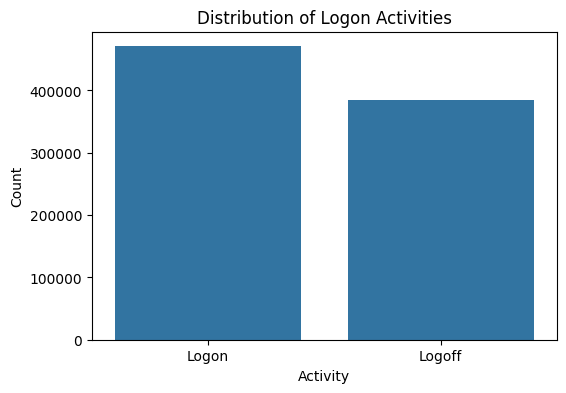

In [13]:
logon_activity = (
    datasets["logon"]
    .group_by("activity")
    .len()
    .sort("len", descending=True)
    .collect()
)

logon_activity

logon_activity_pd = logon_activity.to_pandas()

plt.figure(figsize=(6,4))

sns.barplot(
    data=logon_activity_pd,
    x="activity",
    y="len"
)

plt.title("Distribution of Logon Activities")
plt.xlabel("Activity")
plt.ylabel("Count")

plt.show()

## Device Dataset Analysis
**Which USB device activities occur most frequently?**

In [14]:
device_activity = (
    datasets["device"]
    .group_by("activity")
    .len()
    .sort("len", descending=True)
    .collect()
)

device_activity

activity,len
str,u32
"""Connect""",203339
"""Disconnect""",202041


## File Dataset Analysis

**What are the most frequently accessed file types within the organization?**


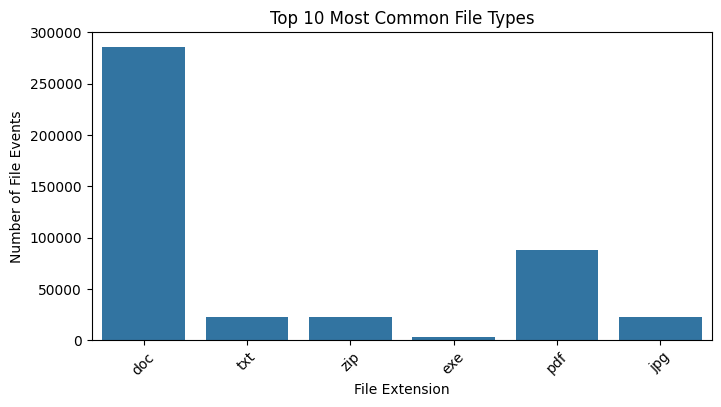

In [15]:
file_types = (
    datasets["file"]
    .with_columns(
        pl.col("filename")
        .str.extract(r"\.([A-Za-z0-9]+)$", 1)
        .alias("extension")
    )
    .group_by("extension")
    .len()
    .head(10)
    .collect()
)

file_types
file_types_pd = file_types.to_pandas()

plt.figure(figsize=(8,4))

sns.barplot(
    data=file_types_pd,
    x="extension",
    y="len"
)

plt.title("Top 10 Most Common File Types")
plt.xlabel("File Extension")
plt.ylabel("Number of File Events")

plt.xticks(rotation=45)

plt.show()


## HTTP Dataset Analysis

**Which web URLs are accessed most frequently within the organization?**

In [16]:
http_domains = (
    datasets["http"]
    .with_columns(
        pl.col("url")
        .str.extract(r"https?://([^/]+)", 1)
        .alias("domain")
    )
    .filter(pl.col("domain").is_not_null())
    .group_by("domain")
    .len()
    .sort("len", descending=True)
    .head(10)
    .collect()
)

http_domains

domain,len
str,u32
"""nfl.com""",619672
"""linkedin.com""",472229
"""vistaprint.com""",428795
"""theblaze.com""",424119
"""eonline.com""",371821
"""imdb.com""",342119
"""mediafire.com""",331283
"""shareasale.com""",324737
"""inbox.com""",321268


## Psychometric Dataset Analysis

**How do the average psychometric trait scores vary across the employee population?**

In [17]:
trait_means = (
    datasets["psychometric"]
    .select([
        pl.mean("O"),
        pl.mean("C"),
        pl.mean("E"),
        pl.mean("A"),
        pl.mean("N")
    ])
    .collect()
)

trait_means

O,C,E,A,N
f64,f64,f64,f64,f64
33.173,30.653,29.197,28.821,29.608


**How is user activity distributed across different organizational systems?**


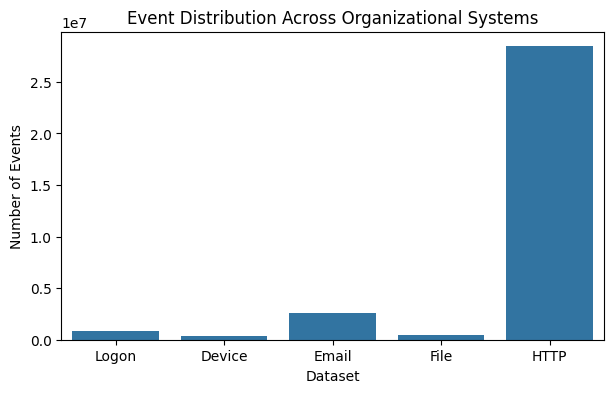

In [18]:
activity_summary = pl.DataFrame({
    "Dataset": ["Logon", "Device", "Email", "File", "HTTP"],
    "Events": [
        datasets["logon"].select(pl.len()).collect().item(),
        datasets["device"].select(pl.len()).collect().item(),
        datasets["email"].select(pl.len()).collect().item(),
        datasets["file"].select(pl.len()).collect().item(),
        datasets["http"].select(pl.len()).collect().item(),
    ]
})

activity_summary

activity_summary_pd = activity_summary.to_pandas()

plt.figure(figsize=(7,4))

sns.barplot(
    data=activity_summary_pd,
    x="Dataset",
    y="Events"
)

plt.title("Event Distribution Across Organizational Systems")
plt.ylabel("Number of Events")

plt.show()

**Which users generate the highest overall activity across multiple organizational systems?**


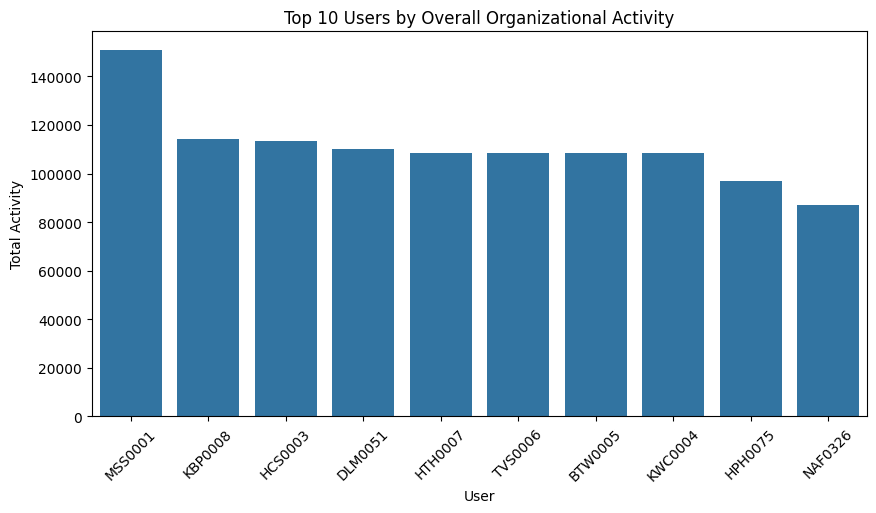

In [19]:
logon_users = datasets["logon"].group_by("user").len()
device_users = datasets["device"].group_by("user").len()
email_users = datasets["email"].group_by("user").len()
file_users = datasets["file"].group_by("user").len()
http_users = datasets["http"].group_by("user").len()

all_users = pl.concat([
    logon_users,
    device_users,
    email_users,
    file_users,
    http_users
])

top_users = (
    all_users
    .group_by("user")
    .agg(pl.col("len").sum().alias("Total Activity"))
    .sort("Total Activity", descending=True)
    .head(10)
    .collect()
)

top_users

top_users_pd = top_users.to_pandas()

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_users_pd,
    x="user",
    y="Total Activity"
)

plt.title("Top 10 Users by Overall Organizational Activity")
plt.xlabel("User")
plt.ylabel("Total Activity")

plt.xticks(rotation=45)

plt.show()